A força de atração gravitacional que um corpo de massa $m_1$ exerce no corpo de massa $m_2$ é modelada segundo a lei de gravitação universal de Newton, dada pela equação $$\vec{F}_{12} =  -\frac{Gm_1m_2}{{r}^2}\vec{e}_{12}$$
em que $G$ é a constante de gravitação universal, $r$ a distância entre os corpo e $\vec{e}_{12}$ o vetor unitário direcionado do primeiro para o segundo corpo.

Na modelagem do movimento de corpos celestes no sistema solar é usado o seguinte sistema de unidades fundamentais:

* Comprimento: $1 \,{AU}$ (Unidade Astronômica $\approx$ Distância média Terra-Sol);
* Massa: $1 \,{M}_{\odot}$ (Massa do Sol $\approx 1.98\times 10^{30}\,kg$);
* Tempo: $1\,ano$.

Para a constante de gravitação universal temos que
$$ G = 4\pi^2\;\frac{AU^3}{{M}_{\odot}\times ano^2}.$$


## Tarefa #1:

Implemente um código em Python para simular o movimento do sistema Sol-Terra.

a)  Calcule a evolução do sistema para um período de $2\,\text{anos}$, usando os seguintes dados:


*   Terra:
    1.   Posição inicial: $x_0 = 0.9832\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = 6.2835\,AU/ano$,
    3.   Massa: $m_1 = 3.003\times 10^{-6}\,{M}_{\odot}$
*   Sol:
    1.   Posição inicial: $x_0 = -2.95\times 10^{-6}\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = -1.887\times 10^{-5}\,AU/ano$,
    3.   Massa: $m_2 = 1\,{M}_{\odot}$

In [34]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

G = 4.0 * np.pi**2          # UA^3 / (M_sol * ano^2)

massa_terra = 3.003e-6              # massa da Terra [M_sol]
massa_sol = 1.0                  # massa do Sol   [M_sol]

# Condições iniciais
posicoes_terra = np.array([0.9832, 0.0])          # Terra [UA]
velocidades_terra = np.array([0.0, 6.2835])          # Terra [UA/ano]
posicoes_sol = np.array([-2.95e-6, 0.0])        # Sol   [UA]
velocidades_sol = np.array([0.0, -1.887e-5])       # Sol   [UA/ano]


def calcular_derivadas(t, estado):
    """
    Vetor de estado: [x1, y1, x2, y2, vx1, vy1, vx2, vy2].

    Retorna d(estado)/dt usando a lei da gravitação universal.
    """
    r1 = estado[0:2]
    r2 = estado[2:4]
    v1 = estado[4:6]
    v2 = estado[6:8]

    d = r2 - r1
    dist = np.linalg.norm(d)
    inv_r3 = 1.0 / dist**3

    a1 = G * massa_sol * d * inv_r3
    a2 = -G * massa_terra * d * inv_r3

    return np.concatenate((v1, v2, a1, a2))


t_total = 2.0                          
t_span = (0.0, t_total)
t_eval = np.linspace(*t_span, 2000)   

estado_0 = np.concatenate((posicoes_terra, posicoes_sol, velocidades_terra, velocidades_sol))

solucao = solve_ivp(
    calcular_derivadas,
    t_span,
    estado_0,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

t = solucao.t
x_terra, y_terra = solucao.y[0], solucao.y[1]    
x_sol, y_sol = solucao.y[2], solucao.y[3]    

# Distância entre os dois corpos ao longo do tempo
distancia = np.sqrt((x_terra - x_sol)**2 + (y_terra - y_sol)**2)

b) Mostre os gráficos das trajetórias de cada corpo no plano $XY$, da evolução das coordenadas de cada corpo e da distância entre os dois corpos ao longo do tempo.


---


**Observação**: Use as funcionalidades do [NumPy](https://numpy.org)  para trabalhar com  vetores (*arrays* de dados), do [SciPy](https://scipy.org/) para a resolução de problemas para EDOs (função [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp)) e do [MatPlotLib](https://matplotlib.org/) para a visualização dos resultados.

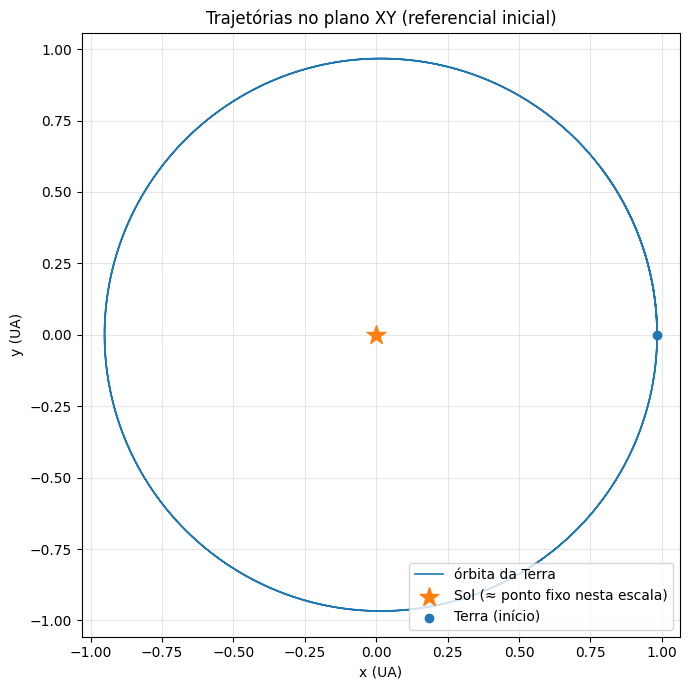

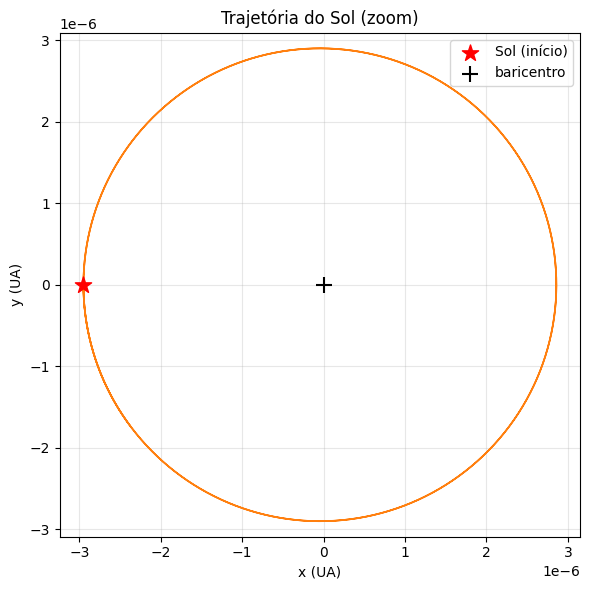

In [35]:
plt.figure(figsize=(7, 7))
plt.plot(x_terra, y_terra, color="tab:blue", lw=1.2, label="órbita da Terra")
# A órbita do Sol (~3e-6 UA) é pequena demais para aparecer nesta escala:
# nela o Sol é praticamente um ponto fixo. Ver o gráfico de zoom para o detalhe.
plt.scatter([x_sol[0]], [y_sol[0]], color="tab:orange", marker="*", s=200,
            zorder=5, label="Sol (≈ ponto fixo nesta escala)")
plt.scatter([x_terra[0]], [y_terra[0]], color="tab:blue", marker="o", zorder=5,
            label="Terra (início)")
plt.xlabel("x (UA)")
plt.ylabel("y (UA)")
plt.title("Trajetórias no plano XY (referencial inicial)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()


xcm = (massa_terra * x_terra + massa_sol * x_sol) / (massa_terra + massa_sol)
ycm = (massa_terra * y_terra + massa_sol * y_sol) / (massa_terra + massa_sol)

plt.figure(figsize=(6, 6))
plt.plot(x_sol, y_sol, color="tab:orange", lw=1.2)
plt.scatter([x_sol[0]], [y_sol[0]], color="red", marker="*", s=150, zorder=5,
            label="Sol (início)")
plt.scatter([xcm.mean()], [ycm.mean()], color="black", marker="+", s=120,
            zorder=6, label="baricentro")
plt.xlabel("x (UA)")
plt.ylabel("y (UA)")
plt.title("Trajetória do Sol (zoom)")
plt.ticklabel_format(style="sci", scilimits=(0, 0), axis="both")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


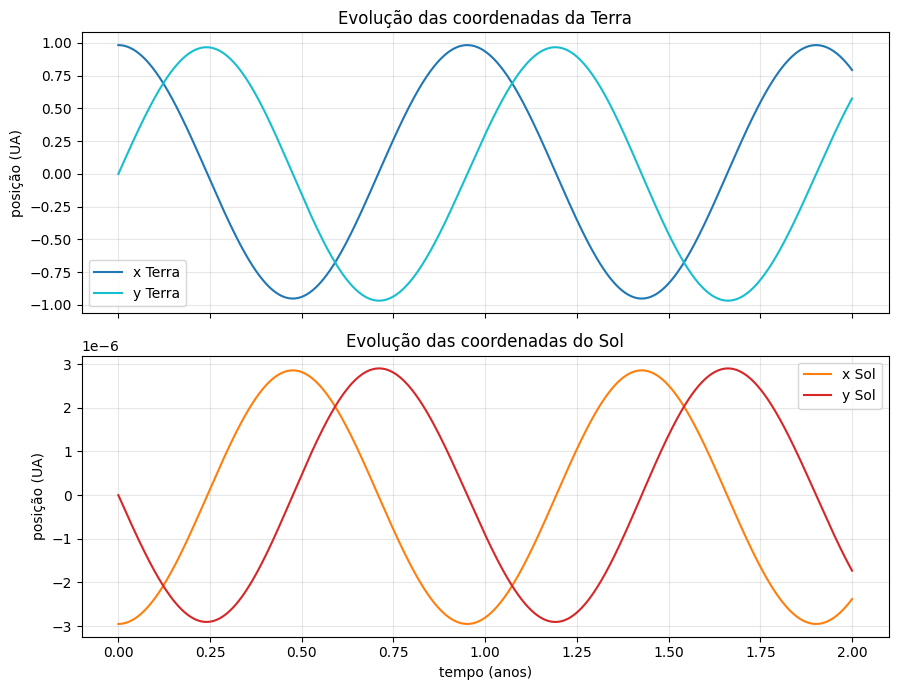

In [36]:
fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axs[0].plot(t, x_terra, label="x Terra", color="tab:blue")
axs[0].plot(t, y_terra, label="y Terra", color="tab:cyan")
axs[0].set_ylabel("posição (UA)")
axs[0].set_title("Evolução das coordenadas da Terra")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(t, x_sol, label="x Sol", color="tab:orange")
axs[1].plot(t, y_sol, label="y Sol", color="tab:red")
axs[1].set_xlabel("tempo (anos)")
axs[1].set_ylabel("posição (UA)")
axs[1].set_title("Evolução das coordenadas do Sol")
axs[1].grid(True, alpha=0.3)
axs[1].legend()
plt.tight_layout()

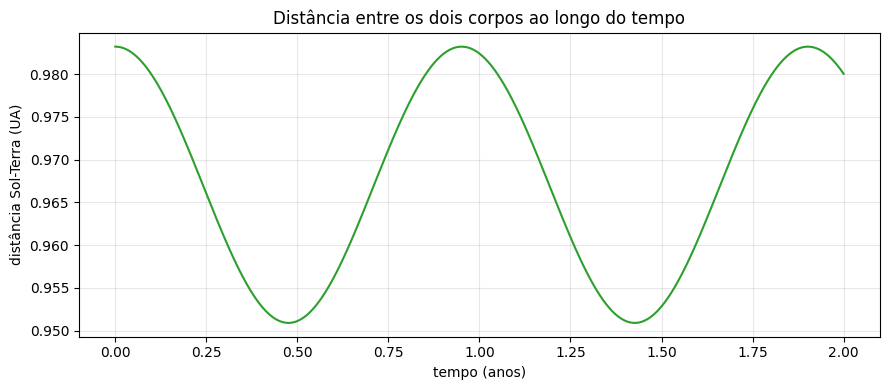

In [37]:
plt.figure(figsize=(9, 4))
plt.plot(t, distancia, color="tab:green")
plt.xlabel("tempo (anos)")
plt.ylabel("distância Sol-Terra (UA)")
plt.title("Distância entre os dois corpos ao longo do tempo")
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [38]:
print(f"Distância inicial : {distancia[0]:.6f} UA")
print(f"Distância mínima  : {distancia.min():.6f} UA")
print(f"Distância máxima  : {distancia.max():.6f} UA")
print(f"Distância média   : {distancia.mean():.6f} UA")

Distância inicial : 0.983203 UA
Distância mínima  : 0.950912 UA
Distância máxima  : 0.983203 UA
Distância média   : 0.967931 UA


## Tarefa #2:

Implemente um código em Python para simular a evolução de um sistema de três estrelas.

a)  Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:

*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533/(4\pi^2)\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$

In [39]:
G = 4.0 * np.pi**2          # UA^3 / (M_sol * ano^2)

massas = np.array([
    0.02533 / (4.0 * np.pi**2),     # estrela 1
    0.02533,                        # estrela 2
    0.02533,                        # estrela 3
])
N = len(massas)


def calcular_derivadas(t, estado, massas):
    """
    Vetor de estado disposto como:
        [ r_0 (2), r_1 (2), ..., v_0 (2), v_1 (2), ... ]

    ou seja, primeiro todas as posições (x_i, y_i) e depois todas as
    velocidades (vx_i, vy_i). Retorna d(estado)/dt.
    """
    n = len(massas)
    pos = estado[:2 * n].reshape(n, 2)
    vel = estado[2 * n:].reshape(n, 2)

    acc = np.zeros_like(pos)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            d = pos[j] - pos[i]
            dist = np.linalg.norm(d)
            acc[i] += G * massas[j] * d / dist**3

    return np.concatenate((vel.ravel(), acc.ravel()))


def simular(pos0, vel0, t_total, n_pts=4000):
    """Integra o sistema e devolve (t, pos[n,2,nt], sol)."""
    estado_0 = np.concatenate((pos0.ravel(), vel0.ravel()))
    t_eval = np.linspace(0.0, t_total, n_pts)
    solucao = solve_ivp(
        calcular_derivadas,
        (0.0, t_total),
        estado_0,
        t_eval=t_eval,
        args=(massas,),
        method="DOP853",
        rtol=1e-11,
        atol=1e-12,
    )
    n = len(massas)
    pos = solucao.y[:2 * n].reshape(n, 2, -1)  
    return solucao.t, pos, solucao


def plotar(t, pos):
    """Gera os três gráficos pedidos: trajetórias XY, evolução das
    coordenadas e distâncias mútuas entre as estrelas."""
    cores = ["tab:blue", "tab:orange", "tab:green"]
    nomes = ["Estrela 1", "Estrela 2", "Estrela 3"]

    # (1) Trajetórias no plano XY
    plt.figure(figsize=(7, 7))
    for i in range(N):
        plt.plot(pos[i, 0], pos[i, 1], color=cores[i], lw=1.0, label=nomes[i])
        plt.scatter([pos[i, 0, 0]], [pos[i, 1, 0]], color=cores[i],
                    marker="o", zorder=5)
    plt.xlabel("x (UA)")
    plt.ylabel("y (UA)")
    plt.title(f"Trajetórias no plano XY")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # (2) Evolução das coordenadas de cada estrela
    fig, axs = plt.subplots(N, 1, figsize=(9, 9), sharex=True)
    for i in range(N):
        axs[i].plot(t, pos[i, 0], color=cores[i], label=f"x {nomes[i]}")
        axs[i].plot(t, pos[i, 1], color=cores[i], ls="--", label=f"y {nomes[i]}")
        axs[i].set_ylabel("posição (UA)")
        axs[i].set_title(f"Coordenadas — {nomes[i]}")
        axs[i].grid(True, alpha=0.3)
        axs[i].legend(loc="upper right")
    axs[-1].set_xlabel("tempo (anos)")
    fig.suptitle(f"Evolução das coordenadas")
    plt.tight_layout()

    # (3) Distâncias mútuas ao longo do tempo
    pares = [(0, 1), (0, 2), (1, 2)]
    plt.figure(figsize=(9, 4))
    for (i, j) in pares:
        d = np.sqrt((pos[i, 0] - pos[j, 0])**2 + (pos[i, 1] - pos[j, 1])**2)
        plt.plot(t, d, label=f"|{nomes[i]} - {nomes[j]}|")
    plt.xlabel("tempo (anos)")
    plt.ylabel("distância (UA)")
    plt.title(f"Distâncias mútuas")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


def resumir(pos):
    """Imprime mínimo, máximo e média das distâncias mútuas."""
    pares = [(0, 1), (0, 2), (1, 2)]
    for (i, j) in pares:
        d = np.sqrt((pos[i, 0] - pos[j, 0])**2 + (pos[i, 1] - pos[j, 1])**2)
        print(f"  d({i+1},{j+1}):  min={d.min():.4f}  max={d.max():.4f}  "
              f"média={d.mean():.4f} UA")


pos0_a = np.array([
    [0.970043, -0.243087],   # estrela 1
    [-0.970043, 0.243087],   # estrela 2
    [0.0, 0.0],              # estrela 3
])
vel0_a = np.array([
    [0.466203, 0.432365],
    [0.466203, 0.432365],
    [-0.932406, -0.864730],
])

T = 10.5 
t_a, pos_a, sol_a = simular(pos0_a, vel0_a, T)


b) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

  d(1,2):  min=1.0715  max=10.6081  média=5.0276 UA
  d(1,3):  min=1.0000  max=4.9101  média=2.4717 UA
  d(2,3):  min=0.6807  max=6.6566  média=4.1334 UA


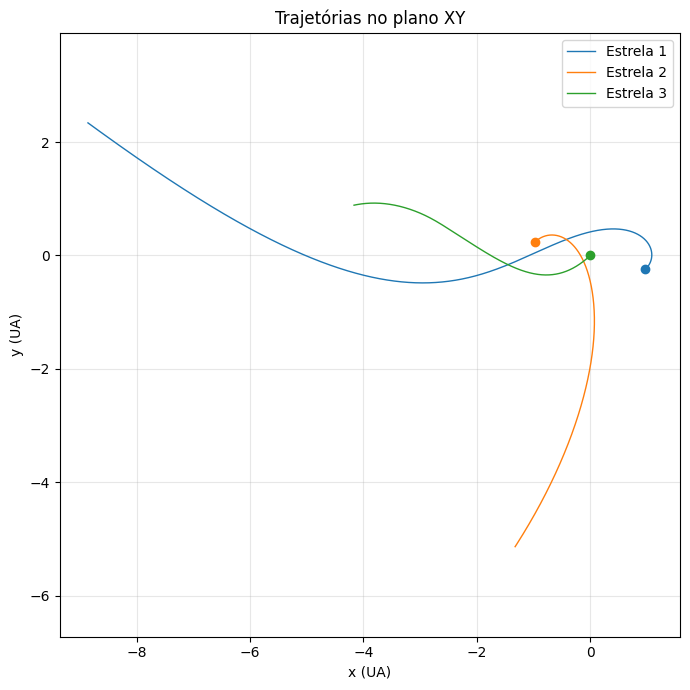

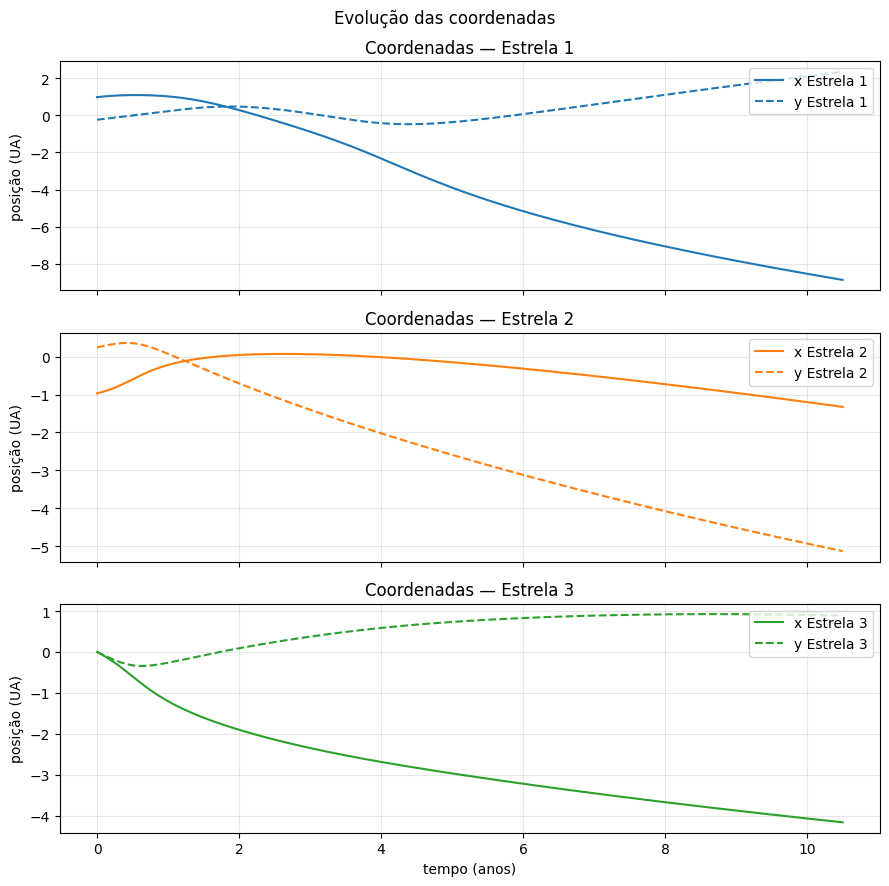

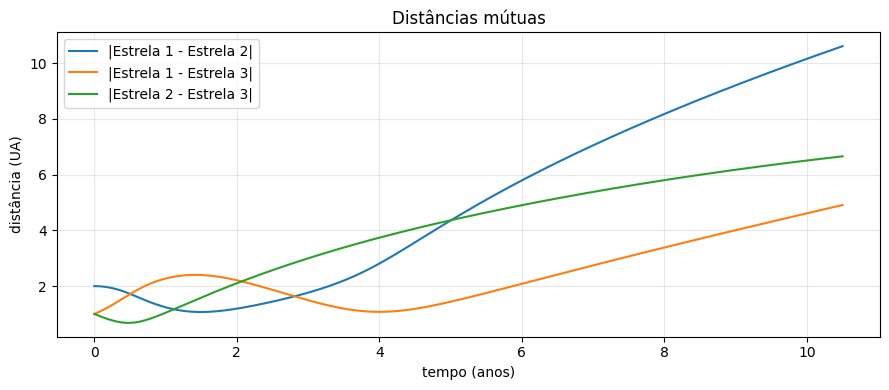

In [40]:
# Gráficos do cenário (a): trajetórias XY, evolução das coordenadas e
# distâncias mútuas entre as estrelas.
plotar(t_a, pos_a)
resumir(pos_a)

c) Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:
*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.166203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533/(4\pi^2)\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.766203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$

In [41]:
# Condições iniciais do cenário (c): diferem de (a) apenas nas componentes
# v0x das estrelas 1 e 2 (a estrela 1 desacelera, a estrela 2 acelera).
pos0_c = pos0_a.copy()
vel0_c = np.array([
    [0.166203, 0.432365],
    [0.766203, 0.432365],
    [-0.932406, -0.864730],
])

t_c, pos_c, sol_c = simular(pos0_c, vel0_c, T)

d) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

  d(1,2):  min=0.4042  max=12.5534  média=6.1354 UA
  d(1,3):  min=1.0000  max=11.2329  média=5.4068 UA
  d(2,3):  min=0.6403  max=10.9836  média=5.9557 UA


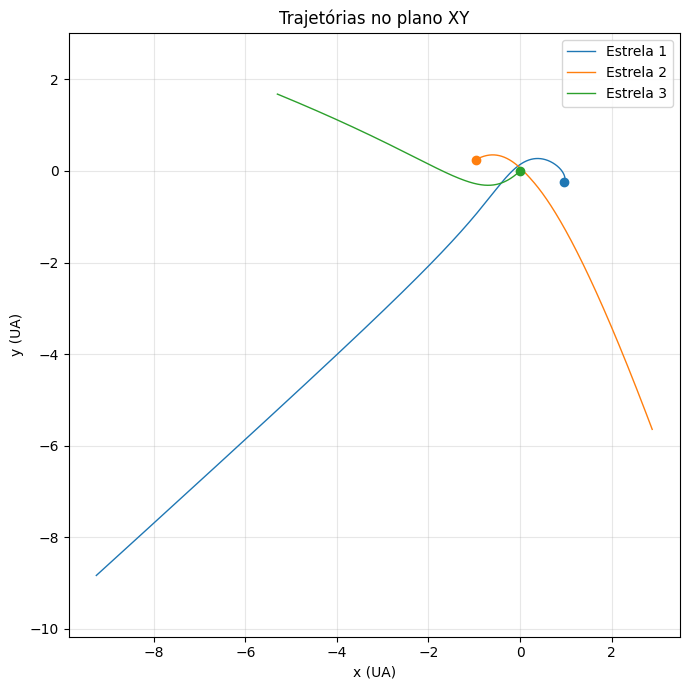

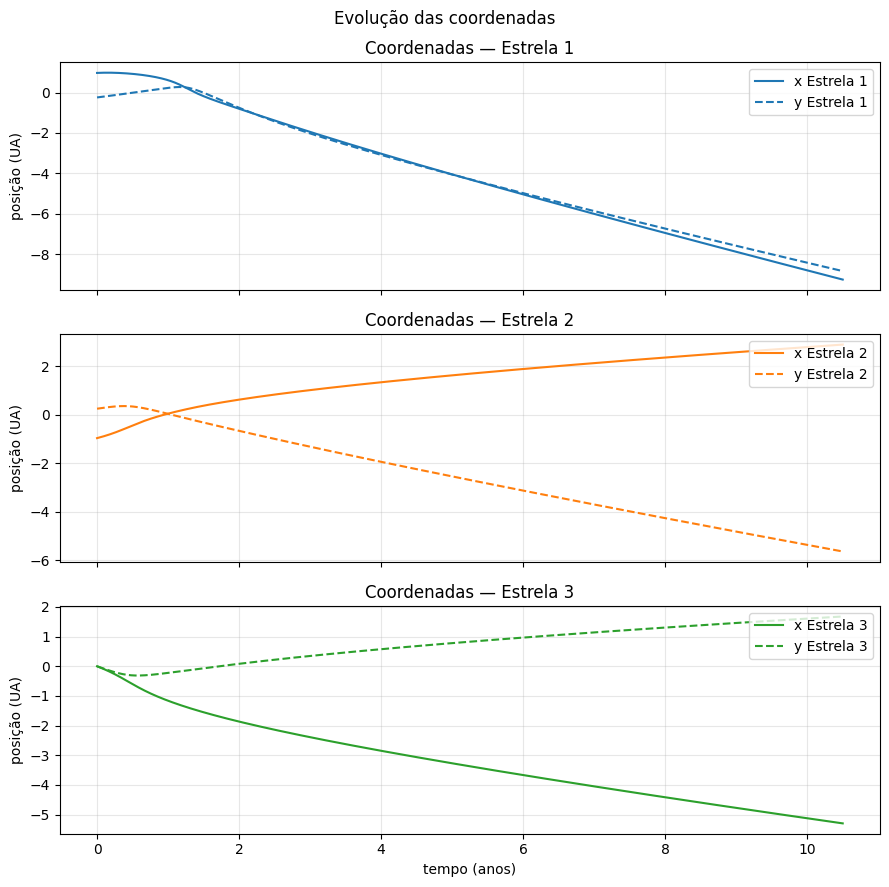

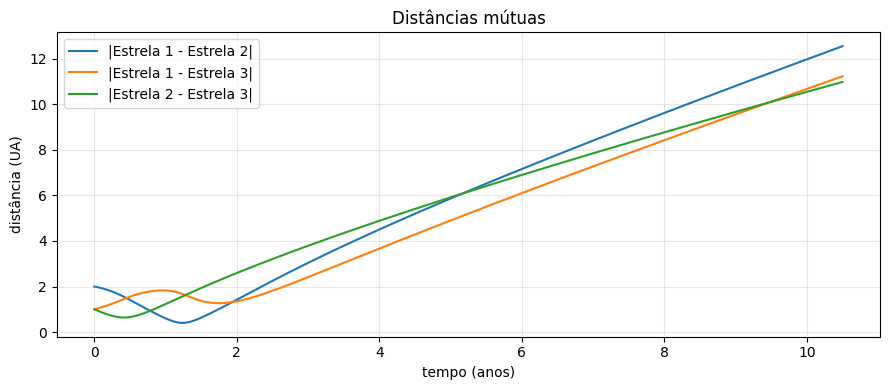

In [42]:
# Gráficos do cenário (c): trajetórias XY, evolução das coordenadas e
# distâncias mútuas entre as estrelas.
plotar(t_c, pos_c)
resumir(pos_c)

e) Descreva qualitativamente os movimentos do sistema calculados nos itens a) e c). Indique semelhanças e diferenças entre esses dois cenários.

**Primeiro cenário**

Fase ligada inicial (~0 a ~4 anos) as três estrelas permanecem próximas (separações oscilando entre ~0.7 e ~2.4 AU), com algumas passagens próximas. Há uma dispersão (depois de ~4–5 anos) o sistema se desliga, as separações passam a crescer de forma monótona. A estrela leve (1) é a que vai mais longe (~7.5 AU do centro de massa ao final), e as três acabam se afastando. O processo é relativamente gradual e ao final (10.5 anos) as distâncias chegam a ~5–10 AU, ainda com um afastamento.

**Segundoi cenário**

A única mudança são as componentes $v_{0x}$ das estrelas 1 e 2 (a 1 desacelera 0.466→0.166; a 2 acelera 0.466→0.766). Isso quebra a simetria das condições iniciais. Encontro por volta de t ~ 1 ano há uma aproximação bem maior entre as estrelas 1 e 2 (mín d₁₂ ~ 0.40 AU, contra 1.07 em (a)). Esse encontro ocorre logo depois que o sistema se desintegra, fazendo com que as separações crescem de modo praticamente linear (retas no gráfico de distâncias), sinal com velocidade constante, atingindo valores maiores (~10–12.5 AU) já aos 10.5 anos. A estrela 1 é lançada num percurso quase retilíneo. 

As semelhanças nesses dois cenários foram as consideradas do problema: mesmas massas, mesmo intervalo (10.5 anos), mesma física; centro de massa essencialmente em repouso nos dois. Eles também partem das mesmas posições, e o início é consideravelmente parecido. Ambos passam por uma fase de interação próxima oscilatória e depois se desfazem Nenhum dos dois é periódico, em ambos as distâncias crescem sem limite no final.

A maior diferença notada foi que uma mudança pequena em duas componentes de velocidade altera a geometria do encontro próximo e, por consequência, todo o destino do sistema.

## Relatório

*(Escreva aqui seu relatório.)*